In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd ..
%cd /content/drive/MyDrive

!pwd
!ls

Mounted at /content/drive
/
/content/drive/MyDrive
/content/drive/MyDrive
 best_model.pkl
 bimlendr_arpit_assignment1_bonus.ipynb
 bimlendr_arpitmit_assignment1_part1_diamond.ipynb
 bimlendr_arpitmit_assignment1_part_3_ridge_regression.ipynb
'bimlendr_assignment0_final (1).ipynb'
 bimlendr_Final_part4main.ipynb
 bonus.ipynb
'Colab Notebooks'
 compressed_image1.png
'Contact Information.gform'
'Copy of bimlendr_arpit_assignment1_part1_emission.ipynb'
'Copy of Bimlendr_Assignment1_checkpoint_diamond.ipynb'
'Copy of Bimlendr_Assignment1_checkpoint_emissionbycountry.ipynb'
 diamond.csv
 diamond_processed.csv
 emissions_by_country.csv
 emissions_by_country_processed.csv
 image1_done.png
 image1.png
 image2_done.png
 image2.png
 linear_regression.csv
 linear_regression_done.csv
 New_York_State_Statewide_COVID-19_Testing__Archived__20241009.csv
 penguins.csv
 recolored_image2.png
'Untitled document.gdoc'


In [2]:
#1 Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. Read, preprocess, and print the main statistics about the dataset.
df = pd.read_csv('diamond.csv')
df.describe()

,average us salary,number of diamonds mined (millions)
count,53940.000000,53940.000000
mean,39521.990100,2.902669
std,5486.892971,1.325985
min,30000.000000,0.600000
25%,34780.000000,1.750000
50%,39547.500000,2.910000
75%,44252.000000,4.050000
max,48999.000000,5.200000


In [4]:
# 3. Handle missing entries
numColumn = ['Unnamed: 0', 'carat', 'average us salary', 'number of diamonds mined (millions)', 'depth', 'table', 'price', 'x', 'y', 'z']
df[numColumn] = df[numColumn].apply(pd.to_numeric, errors='coerce')
dfImputed = df.copy()
dfImputed[numColumn] = dfImputed[numColumn].fillna(dfImputed[numColumn].mean())
dfImputed


,Unnamed: 0,carat,cut,color,clarity,average us salary,number of diamonds mined (millions),depth,table,price,x,y,z
0,1.0,0.23,Ideal,E,SI2,31282,5.01,61.5,55.0,326.0,3.95,3.98,2.43
1,2.0,0.21,Premium,E,SI1,40049,1.69,59.8,61.0,326.0,3.89,3.84,2.31
2,3.0,0.23,Good,E,VS1,33517,3.85,56.9,65.0,327.0,4.05,4.07,2.31
3,4.0,0.29,Premium,I,VS2,38495,3.49,62.4,58.0,334.0,4.20,4.23,2.63
4,5.0,0.31,Good,J,SI2,34178,4.70,63.3,58.0,335.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,53936.0,0.72,Ideal,D,SI1,43892,3.54,60.8,57.0,2757.0,5.75,5.76,3.50
53936,53937.0,0.72,Good,D,SI1,35532,3.51,63.1,55.0,2757.0,5.69,5.75,3.61
53937,53938.0,0.70,Very Good,D,SI1,32133,3.27,62.8,60.0,2757.0,5.66,5.68,3.56
53938,53939.0,0.86,Premium,H,SI2,44248,4.03,61.0,58.0,2757.0,6.15,6.12,3.74


In [5]:
# 4. Handle mismatched string formats.
dfImputed['cut'] = dfImputed['cut'].str.upper()
dfImputed

,Unnamed: 0,carat,cut,color,clarity,average us salary,number of diamonds mined (millions),depth,table,price,x,y,z
0,1.0,0.23,IDEAL,E,SI2,31282,5.01,61.5,55.0,326.0,3.95,3.98,2.43
1,2.0,0.21,PREMIUM,E,SI1,40049,1.69,59.8,61.0,326.0,3.89,3.84,2.31
2,3.0,0.23,GOOD,E,VS1,33517,3.85,56.9,65.0,327.0,4.05,4.07,2.31
3,4.0,0.29,PREMIUM,I,VS2,38495,3.49,62.4,58.0,334.0,4.20,4.23,2.63
4,5.0,0.31,GOOD,J,SI2,34178,4.70,63.3,58.0,335.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,53936.0,0.72,IDEAL,D,SI1,43892,3.54,60.8,57.0,2757.0,5.75,5.76,3.50
53936,53937.0,0.72,GOOD,D,SI1,35532,3.51,63.1,55.0,2757.0,5.69,5.75,3.61
53937,53938.0,0.70,VERY GOOD,D,SI1,32133,3.27,62.8,60.0,2757.0,5.66,5.68,3.56
53938,53939.0,0.86,PREMIUM,H,SI2,44248,4.03,61.0,58.0,2757.0,6.15,6.12,3.74


In [6]:
#5. Handle outliers.
def detectOutliers(df, column):
    quartile1 = df[column].quantile(0.25)
    quartile3 = df[column].quantile(0.75)
    interQuartileRange = quartile3 - quartile1
    lowerLimit = quartile1 - (1.5 * interQuartileRange)
    upperLimit = quartile3 + (1.5 * interQuartileRange)
    outliers = df[(df[column] < lowerLimit) | (df[column] > upperLimit)]
    return outliers, lowerLimit, upperLimit

outliers, lower, uper = detectOutliers(dfImputed, 'price')
new_df = dfImputed.copy()
mean_PCapita = new_df[(new_df['price'] >= lower) & (new_df['price'] <= uper)]['price'].mean()
new_df['price'] = new_df['price'].apply(
    lambda x: mean_PCapita if x < lower or x > uper else x
)
new_df.to_csv('diamond_processed.csv', index=False)
print('outliers length based on price ', len(outliers))
print('data frame length ',len(new_df))

outliers length based on price  3694
data frame length  53940


<Axes: ylabel='price'>

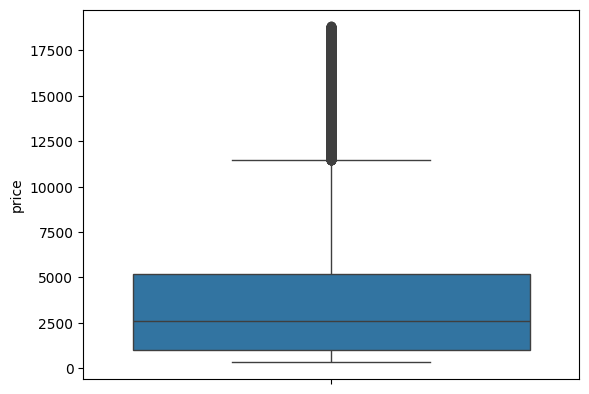

In [7]:
# 6. Visualization Graph
sns.boxplot(dfImputed['price'])

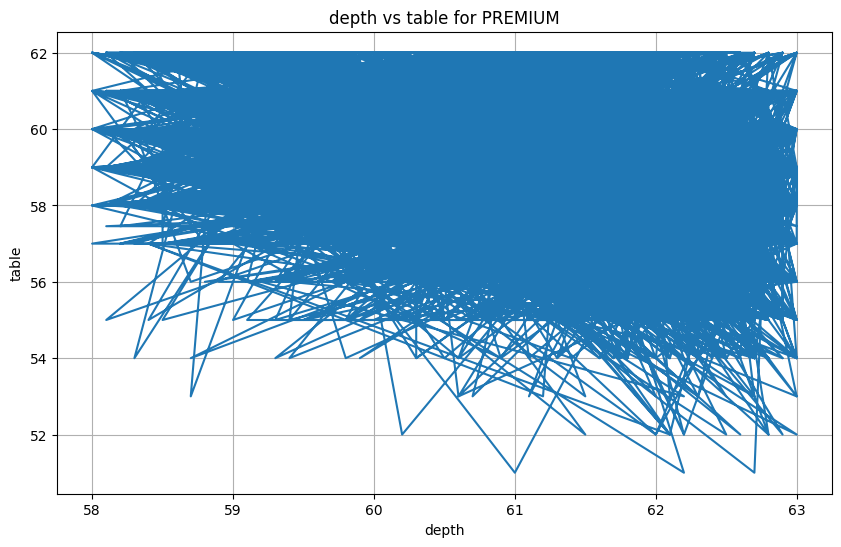

In [8]:
cutData = new_df[new_df['cut'] == 'PREMIUM']
plt.figure(figsize=(10,6))
plt.plot(cutData['depth'], cutData['table'])
plt.title('depth vs table for PREMIUM')
plt.xlabel('depth')
plt.ylabel('table')
plt.grid(True)
plt.show()

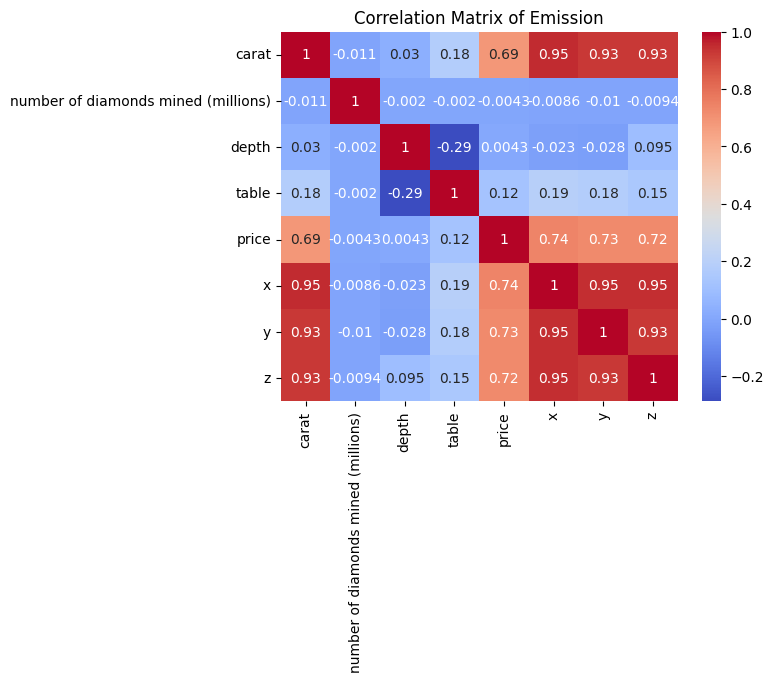

In [9]:
correlation = new_df[['carat', 'number of diamonds mined (millions)', 'depth', 'table', 'price', 'x', 'y', 'z']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Emission')
plt.show()

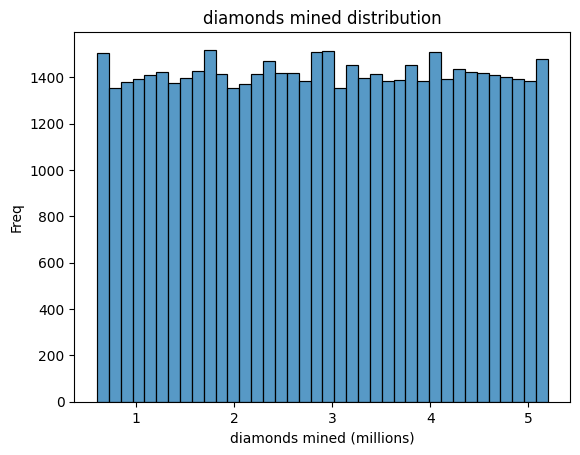

In [10]:
sns.histplot(new_df['number of diamonds mined (millions)'])
plt.title('diamonds mined distribution')
plt.xlabel('diamonds mined (millions)')
plt.ylabel('Freq')
plt.show()

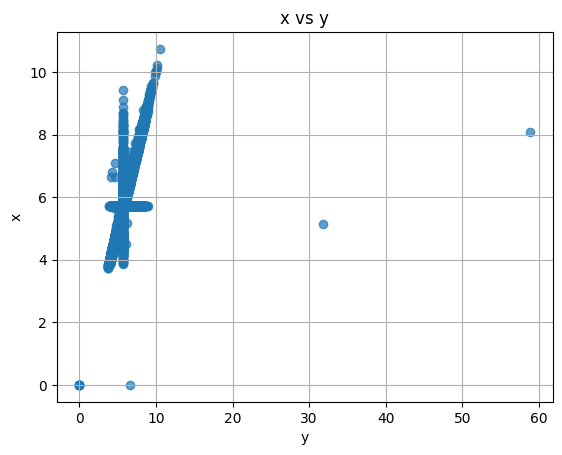

In [11]:
plt.scatter(new_df['y'], new_df['x'], alpha=0.7)
plt.title('x vs y')
plt.xlabel('y')
plt.ylabel('x')
plt.grid(True)
plt.show()

In [12]:
# 7. Identify uncorrelated or unrelated features.
medianSalary = new_df['average us salary'].median()
new_df['High_salary'] = np.where(new_df['average us salary'] > medianSalary, 1, 0)
numColumn = new_df.select_dtypes(include=[np.number])
correlationMatrix = numColumn.corr()
correlationSal = correlationMatrix['High_salary'].sort_values(ascending=False)
correlationSal

,High_salary
High_salary,1.000000
average us salary,0.865897
table,0.002874
z,0.002861
depth,0.002680
carat,0.001687
number of diamonds mined (millions),0.001663
x,0.001592
y,0.000886
price,0.000256


In [13]:
thresholdValue = 0.1
lowCorrelation = correlationSal[correlationSal.abs() < thresholdValue].index.tolist()
new_dfToDrop = new_df.copy()
new_dfToDrop = new_dfToDrop.drop(columns=lowCorrelation)
print("low correlation", lowCorrelation)
new_dfToDrop

low correlation ['table', 'z', 'depth', 'carat', 'number of diamonds mined (millions)', 'x', 'y', 'price', 'Unnamed: 0']


,cut,color,clarity,average us salary,High_salary
0,IDEAL,E,SI2,31282,0
1,PREMIUM,E,SI1,40049,1
2,GOOD,E,VS1,33517,0
3,PREMIUM,I,VS2,38495,0
4,GOOD,J,SI2,34178,0
...,...,...,...,...,...
53935,IDEAL,D,SI1,43892,1
53936,GOOD,D,SI1,35532,0
53937,VERY GOOD,D,SI1,32133,0
53938,PREMIUM,H,SI2,44248,1


In [14]:
# 8. Convert features with string datatype to categorical
encoding = pd.get_dummies(new_dfToDrop, columns=['cut', 'clarity', 'color'], drop_first=True)
encoding.head(5)

,average us salary,High_salary,cut_FALSE,cut_GOOD,cut_IDEAL,cut_MAYBE,cut_PREMIUM,cut_TRUE,cut_VERY GOOD,clarity_I1,...,color_J,color_MAYBE,color_TRUE,color_d,color_e,color_f,color_g,color_h,color_i,color_j
0,31282,0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,40049,1,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,33517,0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,38495,0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,34178,0,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [15]:
# 9. Normalize non-categorical features
minimum = encoding.min()
maximum = encoding.max()
norm = encoding.copy()
for column in norm.columns:
    if norm[column].dtype in ['float64', 'int64']:
        norm[column] = (norm[column] - minimum[column]) / (maximum[column] - minimum[column])
norm

,average us salary,High_salary,cut_FALSE,cut_GOOD,cut_IDEAL,cut_MAYBE,cut_PREMIUM,cut_TRUE,cut_VERY GOOD,clarity_I1,...,color_J,color_MAYBE,color_TRUE,color_d,color_e,color_f,color_g,color_h,color_i,color_j
0,0.067477,0.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.528923,1.0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.185115,0.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.447129,0.0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.219906,0.0,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.731196,1.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
53936,0.291173,0.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
53937,0.112269,0.0,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
53938,0.749934,1.0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Referenced used:
1. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html#pandas.DataFrame.apply
2. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
3. https://matplotlib.org/stable/users/explain/quick_start.html
4. https://seaborn.pydata.org/api.html
5. https://medium.com/@pp1222001/outlier-detection-and-removal-using-the-iqr-method-6fab2954315d
6. https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html


